# Ejercicio de clasificación: detección de Burnout Laboral

**Autores:** `Manuel Dueñas | Alejandro Galvez`

# 1. Obtención de datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd

df = pd.read_csv("https://drive.google.com/uc?export=download&id=1vSy8L9oKQtSJcV_0a0k_elgYWoabbkBd")

Los datos utilizados en este proyecto provienen del dataset público **"Mental Health Corpus"**, disponible en el repositorio de [Kaggle](https://www.kaggle.com/datasets/reihanenamdari/mental-health-corpus/data).


El dataset no está específicamente especializado en burnout, sino que abarca diversos síntomas relacionados con la salud mental, como la ansiedad y la depresión. No obstante, resulta adecuado para realizar una estimación de este fenómeno, ya que comparte características y patrones comunes con el burnout.

# 2. Descripción de los datos



El conjunto de datos presenta una estructura sencilla, en la que cada registro corresponde a un fragmento de texto etiquetado en función del estado emocional o psicológico de su autor.

Las columnas principales que utilizaremos para el entrenamiento del modelo son:
* **text:** Contiene el fragmento de texto original (entrada de diario, post o comentario).

* **label:** Variable objetivo binaria donde $0$ indica un estado saludable y $1$ indica un estado de riesgo (ansiedad, depresión o estrés vinculado al burnout).

In [ ]:
# Vista preliminar del conjunto de datos
display(df.head())

# Análisis de la estructura y tipos de datos
df.info()

,text,label
0,dear american teens question dutch person hear...,0
1,nothing look forward lifei dont many reasons k...,1
2,music recommendations im looking expand playli...,0
3,im done trying feel betterthe reason im still ...,1
4,worried year old girl subject domestic physic...,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27977 entries, 0 to 27976
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    27977 non-null  object
 1   label   27977 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 437.3+ KB


Al analizar la estructura del dataset mediante `df.info()`, observamos la integridad de las columnas:
* **text:** 27,977 registros no nulos.
* **label:** 27,977 registros no nulos.

A diferencia de otros conjuntos de datos de texto, este presenta una **integridad del 100%**, sin valores nulos en ninguna de sus columnas, lo que permite proceder directamente al análisis.

# 3. Exploración y visualización de los datos

En esta etapa, analizamos la distribución de las clases y las características de los textos para entender mejor el balance del problema de clasificación y la longitud de las entradas.

### Gráfica circular de la proporción entre "Saludable" y "Riesgo"

Recuento por clase:
label
0    14139
1    13838
Name: count, dtype: int64


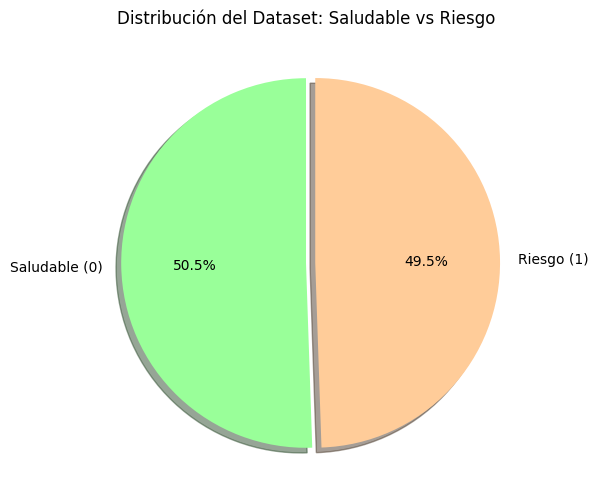

In [ ]:
# Conteo de muestras
conteo = df['label'].value_counts()
print("Recuento por clase:")
print(conteo)

plt.figure(figsize=(6, 6))
colores = ['#99ff99', '#ffcc99']

plt.pie(conteo,
        labels=['Saludable (0)', 'Riesgo (1)'],
        autopct='%1.1f%%',
        startangle=90,
        colors=colores,
        explode=(0, 0.05),
        shadow=True)

plt.title('Distribución del Dataset: Saludable vs Riesgo')
plt.show()

### Análisis de balance de clases

Como se observa en la gráfica, las proporciones son prácticamente simétricas (**50.5%** vs **49.5%**).

Esto constituye una **ventaja significativa** para el entrenamiento del modelo, ya que evita problemas de desbalanceo (donde el modelo aprende a predecir siempre la clase mayoritaria). Al tener una distribución tan equitativa, el algoritmo podrá aprender a identificar patrones de "Saludable" y "Riesgo" con la misma eficacia, permitiéndonos utilizar métricas estándar como la precisión (*accuracy*) con total confianza.

## Diferencia entre las longitudes de los mensajes

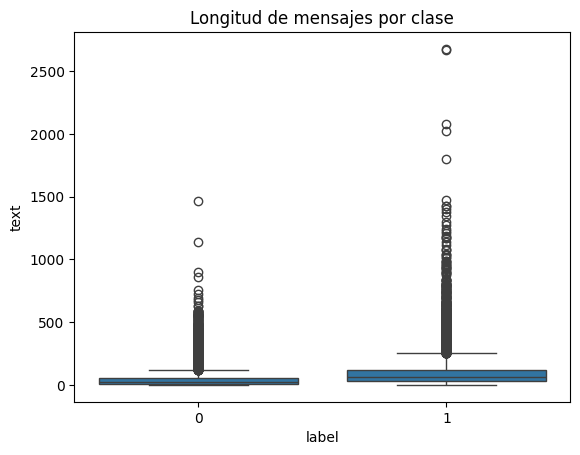

In [ ]:
length_words = df['text'].apply(lambda x: len(str(x).split()))
sns.boxplot(x='label', y=length_words, data=df)
plt.title('Longitud de mensajes por clase')
plt.show()

En el dataset se observa que los mensajes asociados a personas con problemas de salud mental tienden a ser significativamente más extensos que aquellos correspondientes a individuos sin estas condiciones.

Esta diferencia en la longitud de los textos puede introducir un sesgo en el modelo, ya que existe el riesgo de que aprenda a asociar la cantidad de palabras con la presencia de un problema, en lugar de centrarse en el contenido semántico del mensaje. Como consecuencia, el modelo podría generar predicciones incorrectas, clasificando textos largos como problemáticos y textos breves como saludables, independientemente de su significado real.

# 4. Exposición del objetivo

El objetivo principal de este proyecto es desarrollar un modelo de **Aprendizaje Automático (Machine Learning)** capaz de analizar patrones lingüísticos en comunicaciones escritas y clasificar el estado del autor en dos categorías: **Saludable** o **Riesgo de Burnout**.

Para ello, se emplearán técnicas de procesamiento de lenguaje natural (NLP) para la normalización y vectorización de los textos. El fin último es comparar diversos algoritmos de clasificación para identificar cuál ofrece el mejor rendimiento y precisión, permitiendo así una detección temprana de este trastorno emocional que afecta gravemente al ámbito laboral.

# 5.  Preparación de los datos para los algoritmos de Machine Learning

## Normalización de texto

In [ ]:
import re

def preprocess_text(text):
    text = text.lower().strip()

    # Eliminar URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Eliminar menciones y hashtags
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)

    # Eliminar caracteres especiales
    text = re.sub(r'[^\w\s]', '', text)

    return text


# Aplicar preprocesamiento del texto
df['text'] = df['text'].apply(preprocess_text)

## Vectorización

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),  # Incluir unigramas, bigramas (trigramas funcionan algo peor)
    min_df=3,            # Ignorar términos que aparecen menos de 3 veces
    max_df=0.9,          # Ignorar términos que aparecen en más del 90% de documentos
    stop_words='english',
    sublinear_tf=True,   # Reduce el peso de palabras extremadamente frecuentes y mejora la estabilidad del modelo
    norm='l2'            # Hace que documentos largos y cortos sean comparables
)


In [ ]:
# Vectoriza el texto
X = vectorizer.fit_transform(df["text"])
y = df['label']

# 6. Entrenamiento del modelo

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=23,
    stratify=y
)

In [ ]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, roc_auc_score, brier_score_loss, confusion_matrix

In [ ]:
from sklearn.linear_model import LogisticRegression


lr_model = LogisticRegression(
    C=0.5,
    max_iter=1000,
    class_weight='balanced',
    random_state=23,
    solver='liblinear'
)

# Calibra el modelo con validación cruzada
lr_calibrated = CalibratedClassifierCV(
    lr_model,
    cv=10,
    method='sigmoid'
)

lr_calibrated.fit(X_train, y_train)
y_pred_lr = lr_calibrated.predict(X_test)

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      2828
           1       0.92      0.91      0.92      2768

    accuracy                           0.92      5596
   macro avg       0.92      0.92      0.92      5596
weighted avg       0.92      0.92      0.92      5596



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV

rf_base = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight='balanced',
    random_state=23,
    n_jobs=-1
)

rf_calibrated = CalibratedClassifierCV(
    rf_base,
    cv=5,
    method='sigmoid'
)

rf_calibrated.fit(X_train, y_train)
y_pred_rf = rf_calibrated.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      2828
           1       0.88      0.82      0.85      2768

    accuracy                           0.86      5596
   macro avg       0.86      0.86      0.86      5596
weighted avg       0.86      0.86      0.86      5596



In [ ]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, roc_auc_score, brier_score_loss

svm_base = LinearSVC(
    class_weight='balanced',
    random_state=23
)

svm_calibrated = CalibratedClassifierCV(
    svm_base,
    cv=5,
    method='sigmoid'
)

svm_calibrated.fit(X_train, y_train)

y_pred_svm = svm_calibrated.predict(X_test)

print("=== LinearSVC ===")
print(classification_report(y_test, y_pred_svm))

=== LinearSVC ===
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      2828
           1       0.92      0.91      0.92      2768

    accuracy                           0.92      5596
   macro avg       0.92      0.92      0.92      5596
weighted avg       0.92      0.92      0.92      5596



# 7. Comprobación del rendimiento

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Rendimiento del Modelo Logistic Regression

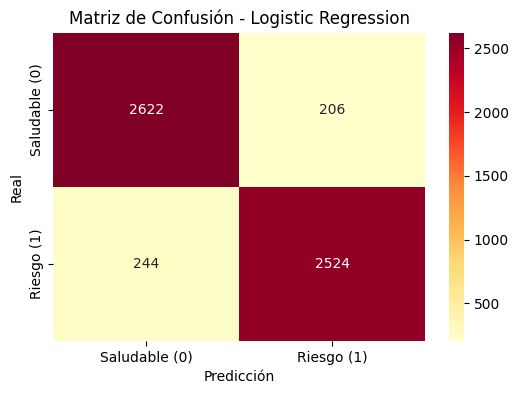


Informe de Clasificación (Logistic Regression):
              precision    recall  f1-score   support

   Saludable       0.91      0.93      0.92      2828
      Riesgo       0.92      0.91      0.92      2768

    accuracy                           0.92      5596
   macro avg       0.92      0.92      0.92      5596
weighted avg       0.92      0.92      0.92      5596

Precisión: 91.96 %


In [ ]:
# Matriz de Confusión para Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['Saludable (0)', 'Riesgo (1)'],
            yticklabels=['Saludable (0)', 'Riesgo (1)'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Logistic Regression')
plt.show()

# Precisión e Informe
print("\nInforme de Clasificación (Logistic Regression):")
print(classification_report(y_test, y_pred_lr, target_names=['Saludable', 'Riesgo']))

accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Precisión: {accuracy_lr * 100:.2f} %")

## Rendimiento del Modelo Random Forest

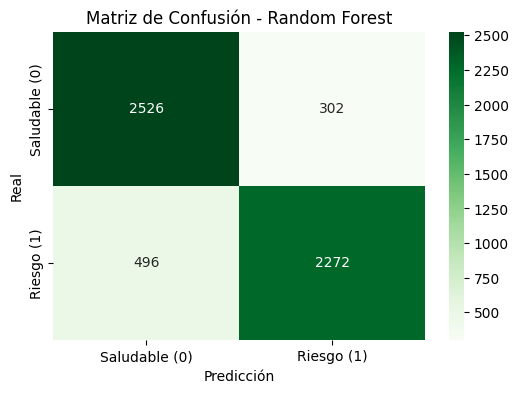


Informe de Clasificación (Random Forest):
              precision    recall  f1-score   support

   Saludable       0.84      0.89      0.86      2828
      Riesgo       0.88      0.82      0.85      2768

    accuracy                           0.86      5596
   macro avg       0.86      0.86      0.86      5596
weighted avg       0.86      0.86      0.86      5596

Precisión: 85.74 %


In [ ]:
# Matriz de Confusión para Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Saludable (0)', 'Riesgo (1)'],
            yticklabels=['Saludable (0)', 'Riesgo (1)'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Random Forest')
plt.show()

# Precisión e Informe
print("\nInforme de Clasificación (Random Forest):")
print(classification_report(y_test, y_pred_rf, target_names=['Saludable', 'Riesgo']))

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Precisión: {accuracy_rf * 100:.2f} %")

## Rendimiento del Modelo LinearSVC

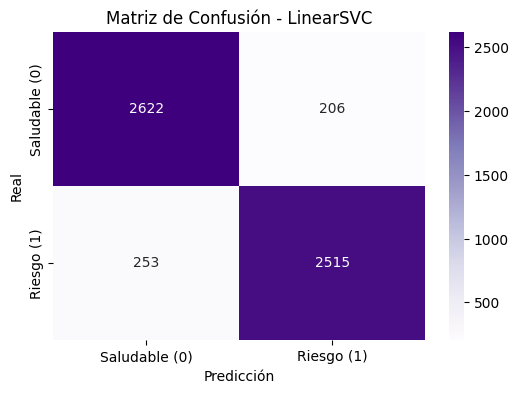


Informe de Clasificación (LinearSVC):
              precision    recall  f1-score   support

   Saludable       0.91      0.93      0.92      2828
      Riesgo       0.92      0.91      0.92      2768

    accuracy                           0.92      5596
   macro avg       0.92      0.92      0.92      5596
weighted avg       0.92      0.92      0.92      5596

Precisión: 91.80 %


In [ ]:
# Matriz de Confusión para LinearSVC
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Saludable (0)', 'Riesgo (1)'],
            yticklabels=['Saludable (0)', 'Riesgo (1)'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - LinearSVC')
plt.show()

# Precisión e Informe
print("\nInforme de Clasificación (LinearSVC):")
print(classification_report(y_test, y_pred_svm, target_names=['Saludable', 'Riesgo']))

accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Precisión: {accuracy_svm * 100:.2f} %")

### Resumen del estudio del rendimiento

Tras realizar las pruebas de rendimiento, el que ha mostrado una mayor precisión ha sido el modelo **Logistic Regression** con un **91.96%**, seguido muy de cerca por la **LinearSVC** con un 91.80 %.

# 7.1 Prueba con textos fuera del dataset

Para comprobar la eficacia del modelo entrenado, vamos a introducir una serie de textos que no han sido utilizados ni para el entrenamiento ni para el test. Estos textos simulan tanto situaciones de estrés y burnout laboral como estados mentales saludables, con el fin de verificar la capacidad de generalización de nuestro algoritmo.

In [ ]:
# PRUEBA COMPARATIVA (SVM vs Regresión Logística)

import pandas as pd

# Definición de 5 textos con patrones de Burnout (Riesgo - 1) y 5 Saludables (0)
textos_prueba = [
    # Casos de Riesgo (1)
    "I haven't slept well in weeks because I keep thinking about my never-ending to-do list. I feel like a robot just going through the motions at the office.",
    "My boss keeps calling me after hours and I feel like I'm going to snap. There is no escape from this stress, I feel trapped and hopeless.",
    "I've lost all interest in my career. I used to love what I do, but now I'm just physically and mentally drained. Everything feels pointless.",
    "The pressure to meet these impossible targets is making me sick. I have constant chest pain and I'm crying in the bathroom during my breaks.",
    "I am so exhausted that I can't even focus on simple tasks. I feel like I'm failing at everything and no one realizes how much I am struggling.",

    # Casos Saludables (0)
    "I really enjoy the collaborative environment at my firm. We always help each other out when things get busy, which keeps the stress low.",
    "Today was a productive day! I finished my main project early and now I'm going to the gym to relax and recharge for tomorrow.",
    "I am grateful for my company's flexibility. Being able to work from home occasionally helps me stay balanced and happy with my life.",
    "Had a great performance review today. It feels good to know that my hard work is recognized and that there are opportunities to grow here.",
    "I love starting my Mondays with a positive mindset. My team is amazing and we have a very healthy atmosphere where communication is key."
]

# Etiquetas reales
labels_reales = [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]

# Preprocesamiento
textos_limpios_prueba = [preprocess_text(t) for t in textos_prueba]

# Vectorización
X_prueba = vectorizer.transform(textos_limpios_prueba)

# Predicciones binarias
preds_svm = svm_calibrated.predict(X_prueba)
preds_lr = lr_calibrated.predict(X_prueba)

# Probabilidades (clase positiva = Riesgo)
proba_svm = svm_calibrated.predict_proba(X_prueba)[:, 1]
proba_lr = lr_calibrated.predict_proba(X_prueba)[:, 1]

# DataFrame comparativo
df_comparativa = pd.DataFrame({
    'Texto de Prueba': textos_prueba,
    'Etiqueta Real': ['Riesgo' if l == 1 else 'Saludable' for l in labels_reales],

    'Predicción SVM': ['Riesgo' if p == 1 else 'Saludable' for p in preds_svm],
    'Probabilidad SVM (%)': (proba_svm * 100).round(2),

    'Predicción LR': ['Riesgo' if p == 1 else 'Saludable' for p in preds_lr],
    'Probabilidad LR (%)': (proba_lr * 100).round(2),
})

# Aciertos
df_comparativa['Acierto SVM'] = df_comparativa['Etiqueta Real'] == df_comparativa['Predicción SVM']
df_comparativa['Acierto LR'] = df_comparativa['Etiqueta Real'] == df_comparativa['Predicción LR']

# Mostrar tabla
display(df_comparativa)

# Resumen final
acc_svm = (df_comparativa['Acierto SVM'].mean()) * 100
acc_lr = (df_comparativa['Acierto LR'].mean()) * 100

print("\n--- RESUMEN DE RENDIMIENTO ---")
print(f"Precisión Final LinearSVC: {acc_svm:.2f}%")
print(f"Precisión Final Regresión Logística: {acc_lr:.2f}%")


,Texto de Prueba,Etiqueta Real,Predicción SVM,Probabilidad SVM (%),Predicción LR,Probabilidad LR (%),Acierto SVM,Acierto LR
0,I haven't slept well in weeks because I keep t...,Riesgo,Riesgo,57.95,Riesgo,62.09,True,True
1,My boss keeps calling me after hours and I fee...,Riesgo,Riesgo,78.33,Riesgo,81.55,True,True
2,I've lost all interest in my career. I used to...,Riesgo,Riesgo,96.44,Riesgo,77.67,True,True
3,The pressure to meet these impossible targets ...,Riesgo,Riesgo,72.95,Riesgo,54.47,True,True
4,I am so exhausted that I can't even focus on s...,Riesgo,Saludable,49.63,Riesgo,52.02,False,True
5,I really enjoy the collaborative environment a...,Saludable,Saludable,38.59,Saludable,41.99,True,True
6,Today was a productive day! I finished my main...,Saludable,Saludable,13.55,Saludable,11.99,True,True
7,I am grateful for my company's flexibility. Be...,Saludable,Riesgo,72.10,Riesgo,73.43,False,False
8,Had a great performance review today. It feels...,Saludable,Saludable,19.13,Saludable,10.44,True,True
9,I love starting my Mondays with a positive min...,Saludable,Saludable,3.35,Saludable,3.83,True,True



--- RESUMEN DE RENDIMIENTO ---
Precisión Final LinearSVC: 80.00%
Precisión Final Regresión Logística: 90.00%


Ambos modelos muestran un desempeño sólido en esta prueba comparativa.
**LinearSVC** alcanzó una precisión del **80%**, mientras que la **Regresión Logística** obtuvo un **90%**.

Las probabilidades asignadas a cada predicción reflejan de manera coherente el grado de riesgo asociado a los textos, con valores más altos para los casos de riesgo y más bajos para los saludables.

Se observan algunos desaciertos, especialmente en textos ambiguos o con indicadores mixtos, lo que sugiere que aunque ambos modelos son efectivos, la Regresión Logística presenta una capacidad ligeramente superior para calibrar la probabilidad y detectar casos límite.

En general, los resultados indican que ambos enfoques pueden ser útiles para la identificación de señales de riesgo relacionadas con el burnout.


# 8. Exposición de conclusiones

En este proyecto, el preprocesamiento de los fragmentos de texto, incluyendo su normalización, junto con la vectorización, fue fundamental para el entrenamiento de los modelos. Estas técnicas permitieron capturar de manera efectiva los patrones lingüísticos asociados a problemas de salud mental de los usuarios, contribuyendo a un desempeño sólido en la clasificación.

Entre los algoritmos evaluados, el modelo de **Regresión Logística** obtuvo el mejor rendimiento, alcanzando una exactitud del **91.96%** en los datos de prueba y demostrando un buen desempeño al analizar textos externos al dataset original.

La integración de estos resultados en nuestra aplicación permitirá identificar patrones y predecir de manera temprana problemas laborales entre los empleados, ofreciendo un recurso valioso para la gestión del bienestar y la prevención del estrés o burnout.

# 9. Exportación de los modelos y el vectorizador


In [ ]:
import joblib

joblib.dump(vectorizer, "tfidf_vectorizer.joblib")
joblib.dump(lr_calibrated, "lr_calibrated_model.joblib")


['lr_calibrated_model.joblib']